In [6]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [9]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Ruta de acceso del dataset
project_folder_path = '/content/drive/MyDrive/Colab Notebooks'

#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v01_version_para_regresion.csv'
#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v02_regresion_ventas_brutas.csv'

dataset = '/content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_ventas.csv'

In [13]:
#cargamos el dataset y mostramos las primeras filas
try:
    df = pd.read_csv(dataset, encoding="ISO-8859-1")
    print(f"Archivo {dataset} cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_ventas.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,1,12,2010,8,2,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,1,12,2010,8,2,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34


In [14]:
#Vista general del dataset

#Dimensiones de dataset
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

#Nombres de las columnas.
print("\nNombres de las columnas:")
print(df.columns)

#Primeras y ultimas 5 filas del dataset
print("\nPrimeras 5 filas del dataset:")
display(df.head())
print("\nUltimas 5 filas del dataset:")
display(df.tail())

#tipos de datos y estructura
print("\nTipos de datos y estructura del dataset:")
display(df.info())

#resumen estadistico
print("\nResumen estadístico del dataset:")
display(df.describe())

#resumen descriptivo
print("\nResumen descriptivo del dataset:")
display(df.describe(include='object'))



Dimensiones del dataset:
Filas: 522010
Columnas: 15

Nombres de las columnas:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
       'InvoiceDay', 'InvoiceMonth', 'InvoiceYear', 'InvoiceHour', 'DayOfWeek', 'IsUk', 'TotalPrice'],
      dtype='object')

Primeras 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,1,12,2010,8,2,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,1,12,2010,8,2,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34



Ultimas 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
522005,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,"12,680.00",France,9,12,2011,12,4,0,10.20
522006,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France,9,12,2011,12,4,0,12.60
522007,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France,9,12,2011,12,4,0,16.60
522008,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France,9,12,2011,12,4,0,16.60
522009,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France,9,12,2011,12,4,0,14.85



Tipos de datos y estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522010 entries, 0 to 522009
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     522010 non-null  int64  
 1   StockCode     522010 non-null  object 
 2   Description   522010 non-null  object 
 3   Quantity      522010 non-null  int64  
 4   InvoiceDate   522010 non-null  object 
 5   UnitPrice     522010 non-null  float64
 6   CustomerID    390600 non-null  float64
 7   Country       522010 non-null  object 
 8   InvoiceDay    522010 non-null  int64  
 9   InvoiceMonth  522010 non-null  int64  
 10  InvoiceYear   522010 non-null  int64  
 11  InvoiceHour   522010 non-null  int64  
 12  DayOfWeek     522010 non-null  int64  
 13  IsUk          522010 non-null  int64  
 14  TotalPrice    522010 non-null  float64
dtypes: float64(3), int64(8), object(4)
memory usage: 59.7+ MB


None


Resumen estadístico del dataset:


,InvoiceNo,Quantity,UnitPrice,CustomerID,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
count,"522,010.00","522,010.00","522,010.00","390,600.00","522,010.00","522,010.00","522,010.00","522,010.00","522,010.00","522,010.00","522,010.00"
mean,"559,962.20",10.32,3.27,"15,295.82",15.02,7.55,"2,010.92",13.08,2.43,0.92,19.09
std,"13,422.16",37.81,4.38,"1,710.32",8.66,3.51,0.27,2.44,1.85,0.28,84.60
min,"536,365.00",1.00,0.00,"12,347.00",1.00,1.00,"2,010.00",6.00,0.00,0.00,0.00
25%,"547,906.00",1.00,1.25,"13,969.00",7.00,5.00,"2,011.00",11.00,1.00,1.00,3.90
50%,"560,690.00",4.00,2.08,"15,159.00",15.00,8.00,"2,011.00",13.00,2.00,1.00,9.90
75%,"571,824.00",12.00,4.13,"16,794.00",22.00,11.00,"2,011.00",15.00,4.00,1.00,17.70
max,"581,587.00","4,800.00",649.50,"18,287.00",31.00,12.00,"2,011.00",20.00,6.00,1.00,"38,970.00"



Resumen descriptivo del dataset:


,StockCode,Description,InvoiceDate,Country
count,522010,522010,522010,522010
unique,3912,4017,18288,38
top,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2011-10-31 14:41:00,United Kingdom
freq,2252,2310,1113,478466


In [15]:
# Getting the number of rows in the dataframe
df.shape[0]

522010

# Preprocesado y transformación de datos




In [18]:

print("\n--- 1. PREPARACIÓN DE DATOS DIARIOS Y FEATURE ENGINEERING ---")

# Rangos exactos (igual que Prophet)
start_train = '2010-12-01'
end_train   = '2011-11-08'
start_val   = '2011-10-09'
end_val     = '2011-11-08'
start_test  = '2011-11-09'
end_test    = '2011-12-09'

def preprocess_for_rf(df, target_col='TotalPrice'):
    # 1. Agregación Diaria
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()
    df_daily = df.groupby('InvoiceDate')[target_col].sum().reset_index()
    df_daily.columns = ['date', 'daily_sales']

    # 2. FEATURE ENGINEERING (Imprescindible para Random Forest)
    # Extraemos componentes de la fecha
    df_daily['month'] = df_daily['date'].dt.month
    df_daily['day_of_month'] = df_daily['date'].dt.day
    df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
    df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)

    # 3. Variables de "Memoria" (Lags)
    df_daily['sales_lag_1'] = df_daily['daily_sales'].shift(1)
    df_daily['sales_lag_7'] = df_daily['daily_sales'].shift(7)

    # 4. NUEVO CONTEXTO AVANZADO: Medias móviles y tendencias
    df_daily['rolling_mean_7'] = df_daily['daily_sales'].shift(1).rolling(window=7).mean()
    df_daily['rolling_mean_30'] = df_daily['daily_sales'].shift(1).rolling(window=30).mean()
    df_daily['trend_1_vs_7'] = df_daily['sales_lag_1'] - df_daily['sales_lag_7']

    # Rellenamos los primeros días que no tienen lag con la media hacia atrás
    df_daily.bfill(inplace=True)

    # 4. División de conjuntos
    df_train = df_daily[(df_daily['date'] >= start_train) & (df_daily['date'] <= end_train)].copy()
    df_val   = df_daily[(df_daily['date'] >= start_val)   & (df_daily['date'] <= end_val)].copy()
    df_test  = df_daily[(df_daily['date'] >= start_test)  & (df_daily['date'] <= end_test)].copy()

    print(f" ==== Reporte de Datos (Random Forest): ====== ")
    print(f"   - Entrenamiento: {len(df_train)} días")
    print(f"   - Validación:    {len(df_val)} días")
    print(f"   - Test Final:    {len(df_test)} días")

    return df_train, df_val, df_test

# Ejecutamos el preprocesado
df_train, df_val, df_test = preprocess_for_rf(df, 'TotalPrice')




--- 1. PREPARACIÓN DE DATOS DIARIOS Y FEATURE ENGINEERING ---
 ==== Reporte de Datos (Random Forest): ====== 
   - Entrenamiento: 278 días
   - Validación:    27 días
   - Test Final:    27 días


 Modelo: RANDOM_FOREST



In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

print("\n--- 2. ENTRENAMIENTO Y OPTIMIZACIÓN (GRID VS RANDOMIZED) ---")

# Definimos las columnas predictoras (X) y el objetivo (y)
features = [
    'month', 'day_of_month', 'day_of_week', 'is_weekend',
    'sales_lag_1', 'sales_lag_7',
    'rolling_mean_7', 'rolling_mean_30', 'trend_1_vs_7'
]
target = 'daily_sales'

X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]
y_test = df_test[target]

# IMPLEMENTACIÓN EXTRA: Definimos el particionado temporal
tscv = TimeSeriesSplit(n_splits=3)

# Ampliamos un poco la malla para que el experimento de tiempos tenga sentido
# Total de combinaciones posibles = 4 * 4 * 3 * 3 = 144 combinaciones
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

# OPCIÓN 1: GridSearchCV (Fuerza Bruta)

print(f"\n1. Iniciando GridSearchCV (Probando TODAS las 144 combinaciones)...")
start_time_grid = time.time()

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time_grid

print(f" -> Tiempo GridSearchCV: {grid_time:.2f} segundos")
print(f" -> Mejores parámetros Grid: {grid_search.best_params_}")



# OPCIÓN 2: RandomizedSearchCV (Muestreo Inteligente)

print("\n2. Iniciando RandomizedSearchCV (Probando SOLO 40 combinaciones al azar)...")
start_time_random = time.time()

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=40,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
random_time = time.time() - start_time_random

print(f" -> Tiempo RandomizedSearchCV: {random_time:.2f} segundos")
print(f" -> Mejores parámetros Randomized: {random_search.best_params_}")


# VEREDICTO FINAL Y SELECCIÓN DE MODELO

print(" RESUMEN DE LA OPTIMIZACIÓN")
print(f"RandomizedSearchCV fue {grid_time/random_time:.1f} veces más rápido")
print("Por ello es que nos quedamos con RandomizedSearchCV")

# Guardamos el mejor modelo encontrado para pasárselo a la Fase 3
# Puedes elegir cuál de los dos pasar; te dejo activado el Randomized por eficiencia
best_rf_model = random_search.best_estimator_



--- 2. ENTRENAMIENTO Y OPTIMIZACIÓN (GRID VS RANDOMIZED) ---

1. Iniciando GridSearchCV (Probando TODAS las 144 combinaciones)...
 -> Tiempo GridSearchCV: 130.89 segundos
 -> Mejores parámetros Grid: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}

2. Iniciando RandomizedSearchCV (Probando SOLO 40 combinaciones al azar)...
 -> Tiempo RandomizedSearchCV: 34.71 segundos
 -> Mejores parámetros Randomized: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
 RESUMEN DE LA OPTIMIZACIÓN
RandomizedSearchCV fue 3.8 veces más rápido
Por ello es que nos quedamos con RandomizedSearchCV


In [22]:
print("\n--- 3. EVALUACIÓN Y VISUALIZACIÓN DEL MES DE TEST con time series split ---")

def evaluate_rf_test(best_model, df_test, X_test, target_col):

    # 1. Hacemos las predicciones
    preds = best_model.predict(X_test)

    # 2. Preparamos el dataframe de evaluación igual que tu compañero
    df_eval = df_test.copy()
    df_eval['actual_sales'] = df_eval[target_col]
    df_eval['predicted_sales'] = preds
    df_eval['prediction_error'] = df_eval['actual_sales'] - df_eval['predicted_sales']

    # 3. Calculamos métricas
    mae = mean_absolute_error(df_eval['actual_sales'], df_eval['predicted_sales'])
    rmse = np.sqrt(mean_squared_error(df_eval['actual_sales'], df_eval['predicted_sales']))
    r2 = r2_score(df_eval['actual_sales'], df_eval['predicted_sales'])

    print(f" Métricas para Random Forest Optimizado:")
    print(f"   - MAE:  {mae:,.2f}  (Error medio en dinero)")
    print(f"   - RMSE: {rmse:,.2f} (Sensible a grandes errores/outliers)")
    print(f"   - R2:   {r2:.4f}  (Capacidad predictiva 0 a 1)")
    print("-" * 30)

    # 4. Gráfica de Ingresos (Exactamente el mismo estilo visual que Prophet)
    ingresos_diarios = df_eval.set_index('date')[['actual_sales', 'predicted_sales']]

    plt.figure(figsize=(14, 7))
    plt.fill_between(ingresos_diarios.index, ingresos_diarios['actual_sales'], color="skyblue", alpha=0.4, label='Ingresos Reales')
    plt.plot(ingresos_diarios.index, ingresos_diarios['predicted_sales'], color="green", lw=2, label='Predicción Random Forest')
    plt.title("Previsión de Ingresos Diarios (€) - Random Forest")
    plt.xlabel("Fecha")
    plt.ylabel("Total Dinero")
    plt.legend()
    plt.show()

    return mae, rmse, df_eval



--- 3. EVALUACIÓN Y VISUALIZACIÓN DEL MES DE TEST con time series split ---


 Métricas para Random Forest Optimizado:
   - MAE:  12,575.46  (Error medio en dinero)
   - RMSE: 18,572.40 (Sensible a grandes errores/outliers)
   - R2:   0.0283  (Capacidad predictiva 0 a 1)
------------------------------


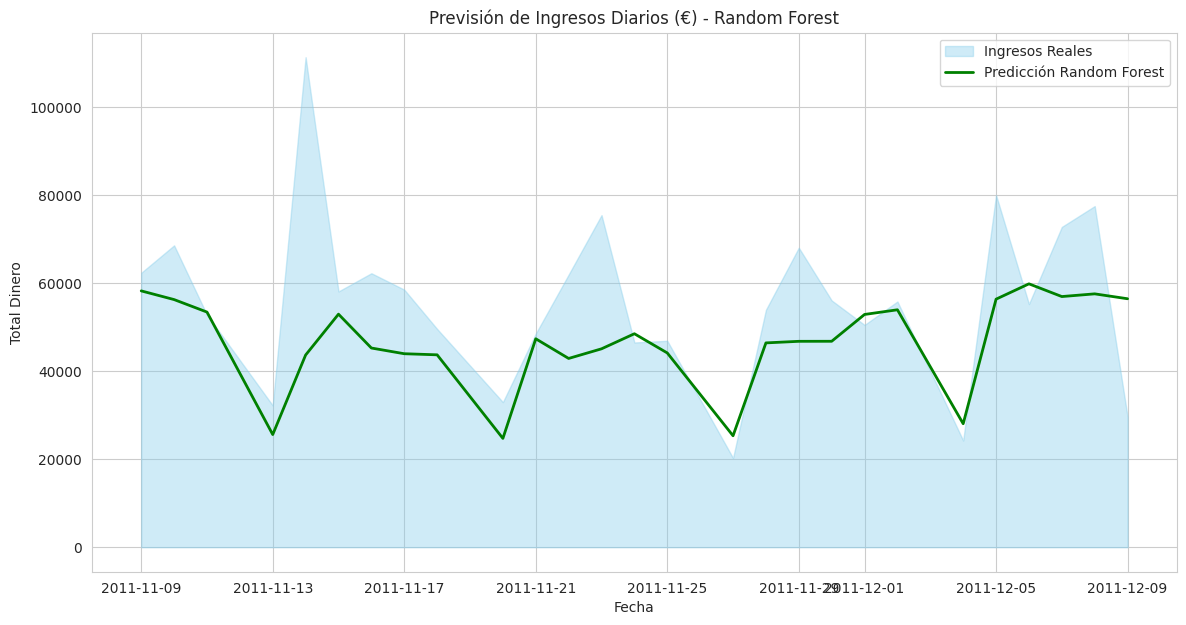

In [23]:
# Lanzamos la evaluación final
mae_rf, rmse_rf, df_eval_rf = evaluate_rf_test(best_rf_model, df_test, X_test, target)


--- 5. IMPORTANCIA DE LAS VARIABLES (CÓMO PIENSA EL MODELO) ---


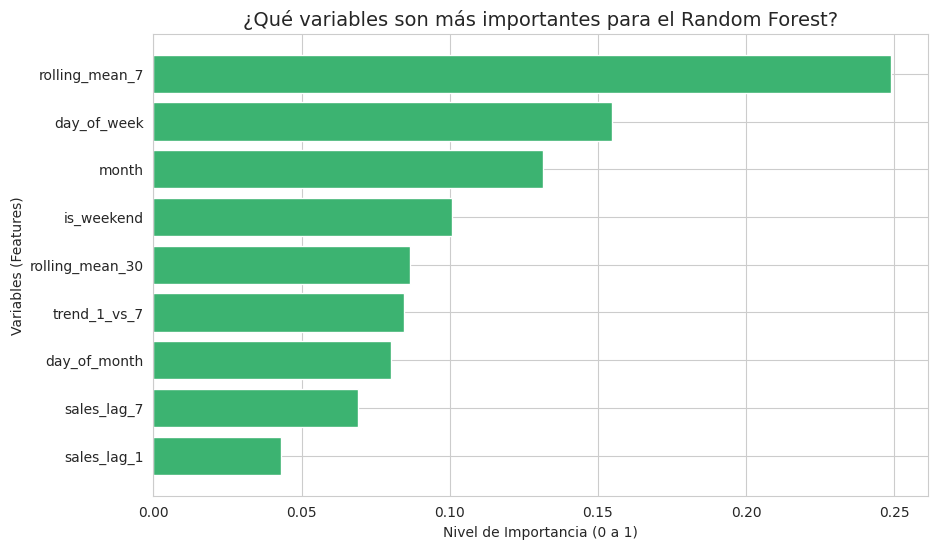

In [24]:
print("\n--- 5. IMPORTANCIA DE LAS VARIABLES (CÓMO PIENSA EL MODELO) ---")

def plot_feature_importance(model, feature_names):
    # Extraemos la importancia matemática de cada variable
    importancias = model.feature_importances_

    # Creamos un DataFrame para ordenarlas
    df_importances = pd.DataFrame({
        'Variable': feature_names,
        'Importancia': importancias
    }).sort_values(by='Importancia', ascending=True) # Ordenamos de menor a mayor para el gráfico

    # Gráfico de barras horizontales
    plt.figure(figsize=(10, 6))
    plt.barh(df_importances['Variable'], df_importances['Importancia'], color='mediumseagreen')
    plt.title("¿Qué variables son más importantes para el Random Forest?", fontsize=14)
    plt.xlabel("Nivel de Importancia (0 a 1)")
    plt.ylabel("Variables (Features)")
    plt.show()

# Lanzamos el gráfico
plot_feature_importance(best_rf_model, features)